In [1]:
# imports
import h5py as h5
import numpy as np
import psutil

from pycorr import TwoPointCorrelationFunction, setup_logging
from colossus.cosmology import cosmology

# Setup pycorr logging to view progress
setup_logging()
psutil.Process().nice(19)

In [23]:
# define bins for s (separation) and mu (cosine of angle to line-of-sight)
s_edges = np.linspace(0.01, 150, 70+1)
mu_edges = np.linspace(0, 1, 120+1)

# path to AbucusSummit halos
halo_path = '/spiffball/cosweeney/simulations/AbacusSummit/halo_base_c000_ph000_z0p100_1e13thresh_pos_vel_mass.hdf5'

L_box = 2_000 # h^-1 Mpc


cosmo = cosmology.setCosmology('planck18')
redshift = 0.100 # z0p100
H = cosmo.Hz(redshift) # Hz in physical km/s/Mpc
h = cosmo.h

with h5.File(halo_path, 'r') as hdf:

    # Load Real Space Positions
    hpos = hdf['pos'][()]

    # Load Z-axis Peculiar Velocities (assuming 'vel' key exists and is in km/s)
    v_z = hdf['vel'][:, 2][()]

    # Ensure positions are strictly within the periodic box boundaries after RSD shift
    hpos = np.mod(hpos, L_box)

    # ---------------------------------------------------------
    # Jackknife Setup: Divide the box into a 3D sub-grid
    # ---------------------------------------------------------
    n_jk_1d = 4 # Yields 4^3 = 64 total jackknife regions
    
    grid_idx = (hpos / L_box * n_jk_1d).astype(int)
    grid_idx = np.clip(grid_idx, 0, n_jk_1d - 1)
    
    # Flatten the 3D grid indices into a 1D array of region IDs
    halo_samples = grid_idx[:, 0] + n_jk_1d * grid_idx[:, 1] + (n_jk_1d**2) * grid_idx[:, 2]

    print('Computing real-space correlation function xi(r)...')
    
    result = TwoPointCorrelationFunction(
        mode='s',
        edges=s_edges,
        data_positions1=hpos,
        data_samples1=halo_samples,
        engine='corrfunc',
        boxsize=L_box,
        #los='z',               
        position_type='pos',
        nthreads=84,
        compute_seps_avg=False
    )


    #Apply rsd, Multiply by h to convert H(z) to h km s^-1 Mpc^-1, matching the box units
    hpos[:, 2] += v_z * (1 + redshift) * h / H

    print('Computing redshift-space correlation function xi(s, mu)...')
    
    red_result = TwoPointCorrelationFunction(
        mode='smu',
        edges=(s_edges, mu_edges),
        data_positions1=hpos,
        data_samples1=halo_samples,
        engine='corrfunc',
        boxsize=L_box,
        los='z',               
        position_type='pos',
        nthreads=84,
        compute_seps_avg=False
    )


Computing real-space correlation function xi(r)...
[002731.17]  07-13 12:02  TwoPointCorrelationFunction  INFO     Using estimator <class 'pycorr.twopoint_jackknife.JackknifeNaturalTwoPointEstimator'>.
[002731.17]  07-13 12:02  TwoPointCorrelationFunction  INFO     Running auto-correlation.
[002731.17]  07-13 12:02  TwoPointCorrelationFunction  INFO     Computing two-point counts D1D2.


/home/cosweeney/miniconda3/envs/tpcf/lib/python3.10/site-packages/pycorr/corrfunc.py:153: UserWarning: These arguments are not read: {'compute_seps_avg': False}
  warnings.warn('These arguments are not read: {}'.format(attrs))


[002751.23]  07-13 12:02  TwoPointCorrelationFunction  INFO     Analytically computing two-point counts R1R2.
[002751.23]  07-13 12:02  TwoPointCorrelationFunction  INFO     Correlation function computed in elapsed time 20.06 s.
Computing redshift-space correlation function xi(s, mu)...
[002751.26]  07-13 12:02  TwoPointCorrelationFunction  INFO     Using estimator <class 'pycorr.twopoint_jackknife.JackknifeNaturalTwoPointEstimator'>.
[002751.26]  07-13 12:02  TwoPointCorrelationFunction  INFO     Running auto-correlation.
[002751.26]  07-13 12:02  TwoPointCorrelationFunction  INFO     Computing two-point counts D1D2.


/home/cosweeney/miniconda3/envs/tpcf/lib/python3.10/site-packages/pycorr/twopoint_counter.py:516: UserWarning: mu edges starting at 0 is deprecated, please use symmetric binning; I am assuming np.linspace(-1.0000, 1.0000, 241)!
  warnings.warn('{} edges starting at 0 is deprecated, please use symmetric binning; I am assuming np.linspace({:.4f}, {:.4f}, {:d})!'.format(axis, -edges[-1], edges[-1], nedges))


[002774.86]  07-13 12:03  TwoPointCorrelationFunction  INFO     Analytically computing two-point counts R1R2.
[002774.86]  07-13 12:03  TwoPointCorrelationFunction  INFO     Correlation function computed in elapsed time 23.60 s.


In [24]:
# get real-space  quantities
xi = result.corr 
xi_cov = result.cov()  

# jackknife 
n_jk_total = n_jk_1d**3
xi_samples = np.array([result.realization(i).corr for i in range(n_jk_total)])

xi_mean = np.mean(xi_samples, axis=0)

# redshift-space quantities
red_xi_s_mu = red_result.corr

red_xi_ell, red_xi_cov = red_result.get_corr(ells=(0, 2, 4), return_cov=True) 

# jackknife 
red_xi_samples = np.array([red_result.realization(i).corr for i in range(n_jk_total)])

red_xi_mean = np.mean(red_xi_samples, axis=0)

s_cens = (s_edges[:-1] + s_edges[1:]) / 2.0
mu_cens = (mu_edges[:-1] + mu_edges[1:]) / 2.0 

In [17]:
red_result.corr.shape

(70, 240)

Text(0.5, 1.0, 'AbacusSummit (base cosmo, z=0.1) True Redshift-space $\\xi_{\\rm hh}(s, \\mu)$')

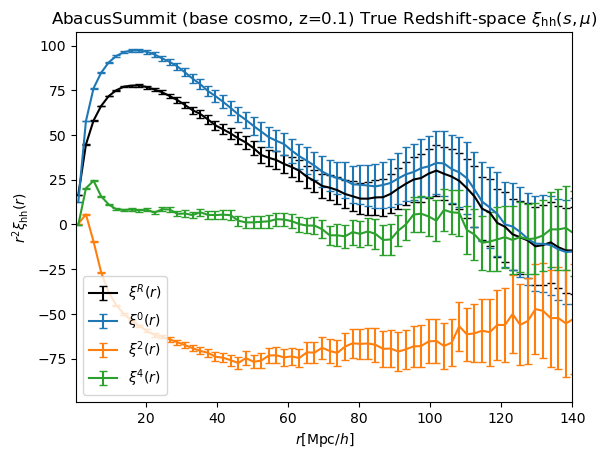

In [26]:
# check 
import matplotlib.pyplot as plt

red_xi_std = np.array_split(np.diag(red_xi_cov)**0.5, 3)


plt.errorbar(s_cens, s_cens**2*xi, s_cens**2*np.sqrt(np.diag(xi_cov)), 
        capsize=3, label=r'$\xi^R(r)$', c='k')

plt.errorbar(s_cens, s_cens**2*red_xi_ell[0], s_cens**2*red_xi_std[0],
        capsize=3, label=r'$\xi^0(r)$')
plt.errorbar(s_cens, s_cens**2*red_xi_ell[1],  s_cens**2*red_xi_std[1],
        capsize=3, label=r'$\xi^2(r)$')
plt.errorbar(s_cens, s_cens**2*red_xi_ell[2],  s_cens**2*red_xi_std[2],
        capsize=3, label=r'$\xi^4(r)$')
plt.legend(loc='lower left')
plt.ylabel(r'$r^2\xi_{\rm hh}(r)$')
plt.xlabel(r'$r [\mathrm{Mpc}/h]$')

plt.xlim((0.5, 140))
#plt.ylim((-30, 20))
#plt.xscale('log')

plt.title(r'AbacusSummit (base cosmo, z=0.1) True Redshift-space $\xi_{\rm hh}(s, \mu)$')

In [28]:
save_path = '/spiffball/cosweeney/simulations/AbacusSummit/data/CorrFuncs/'

with h5.File(save_path+'xi_hh_pycorr.hdf5', 'w') as f:
    f.create_dataset(name='xi', data=xi, dtype=np.float64)
    f.create_dataset(name='xi_cov', data=xi_cov, dtype=np.float64)
    f.create_dataset(name='xi_samples', data=xi_samples, dtype=np.float64)
    f.create_dataset(name='xi_mean', data=xi_mean, dtype=np.float64)
    f.create_dataset(name='s_cens', data=s_cens, dtype=np.float64)
    f.create_dataset(name='s_edges', data=s_edges, dtype=np.float64)
    f.create_dataset(name='mu_cens', data=mu_cens, dtype=np.float64)
    f.create_dataset(name='mu_edges', data=mu_edges, dtype=np.float64)


with h5.File(save_path+'RSCFs/xi_smu_hh_pycorr.hdf5', 'w') as f:
    f.create_dataset(name='xi_s_mu', data=red_xi_s_mu, dtype=np.float64)
    f.create_dataset(name='xi_ell', data=red_xi_ell, dtype=np.float64)
    f.create_dataset(name='xi_ell_cov', data=red_xi_cov, dtype=np.float64)
    f.create_dataset(name='xi_samples', data=red_xi_samples, dtype=np.float64)
    f.create_dataset(name='xi_mean', data=red_xi_mean, dtype=np.float64)
    f.create_dataset(name='s_cens', data=s_cens, dtype=np.float64)
    f.create_dataset(name='s_edges', data=s_edges, dtype=np.float64)
    f.create_dataset(name='mu_cens', data=mu_cens, dtype=np.float64)
    f.create_dataset(name='mu_edges', data=mu_edges, dtype=np.float64)

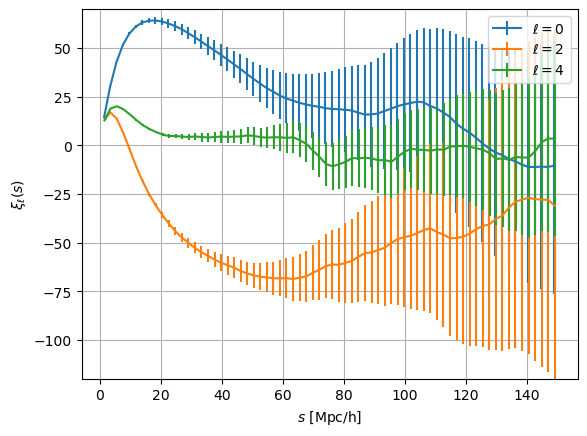

In [32]:
import matplotlib.pyplot as plt

ells = (0, 2, 4)
nells = len(ells)
# Let us rebin by 2 along first dimension (s)
#reresult = result[::2]
s, xiell, cov = result.get_corr(ells=ells, return_sep=True, return_cov=True)
std = np.array_split(np.diag(cov)**0.5, nells)
ax = plt.gca()
for ill,ell in enumerate(ells):
    ax.errorbar(s + ill * 0.1, s**2*xiell[ill], s**2*std[ill], fmt='-', label=r'$\ell = {:d}$'.format(ell))

ax.legend()
ax.grid(True)
ax.set_xlabel(r'$s$ [Mpc/h]')
ax.set_ylabel(r'$\xi_{\ell}(s)$')
plt.ylim((-120, 70))
plt.show()



In [31]:
reresult.shape

(35, 240)

In [40]:
len(result.get_corr(ells=(0, 2, 4), return_cov=True, return_sep=True))

3

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 2 dimensions. The detected shape was (2, 70) + inhomogeneous part.

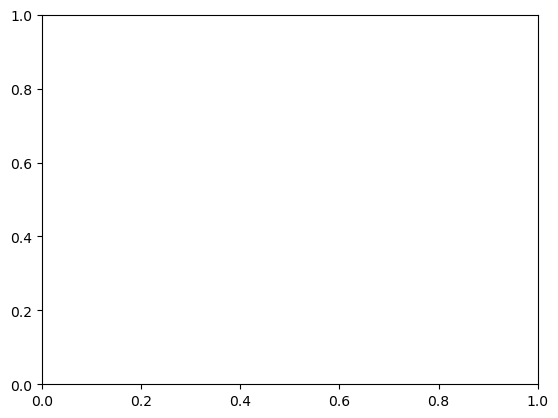

In [ ]:
plt.plot(s, result.get_corr(ell=0, ))